In [17]:
from clean_code.flexible_bitter_llm import FlexibleBitterLLM, LinearGater, text_to_tensor, per_token_losses_backbone
from clean_code.conditional_sequential import OptimizedSequentialyDependentLinearGater, ScaledSequentialyDependentLinearGater
from accelerate import Accelerator
from training_random_base_model.hparam_utils import get_model_kwargs
from transformers import AutoTokenizer
import torch
from torch.utils.data import DataLoader
from data_processing import split_fineweb

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [18]:
byte_tokenizer = AutoTokenizer.from_pretrained("evabyte/EvaByte", trust_remote_code=True)
learned_checkpoint_path = "training_random_base_model/checkpoints/130M_2025.09.26_04.22"
learned_model_kwargs = get_model_kwargs("130M")
learned_model_kwargs["vocab_size"] = len(byte_tokenizer) 
learned_model_kwargs["GaterClass"] = ScaledSequentialyDependentLinearGater

device = torch.device("cuda")

learned_model = FlexibleBitterLLM(**learned_model_kwargs).to(device, dtype=torch.bfloat16)

accelerator = Accelerator()
learned_model = accelerator.prepare(learned_model)
accelerator.load_state(learned_checkpoint_path)

using self._attn_implementation='flash_attention_2'


In [19]:

# TODO once random model is trained: configure the model as an input to this function
model = learned_model

_, _, test_set = split_fineweb.get_splits()

test_dataloader = DataLoader(
    test_set,
    batch_size=32
)

max_seq_length = 4096

next_token_cross_entropies = []
early_next_token_cross_entropies = []
all_gate_probs = []

total_batches = 100 # TODO: add a 0 

with torch.no_grad():
    for i, batch in tqdm(enumerate(test_dataloader), total=total_batches, desc="Processing batches"):
        
        batch, loss_mask = text_to_tensor(
            batch, 
            byte_tokenizer, 
            max_seq_length, 
            device
        )

        out_model = model(batch)
        real_gate_probs = out_model["down_gate_probs"]

        all_gate_probs.append(real_gate_probs)

        per_token_losses = per_token_losses_backbone(
            batch, 
            loss_mask, 
            out_model, 
            real_gate_probs, 
            learn_gating=True,
            early_exit_advantage_estimate=True
        )
        # TODO: use gpt2 tokenizer to see the equivalent "gate probs"

        next_token_cross_entropies.append(per_token_losses["next_token_cross_entropy"])
        early_next_token_cross_entropies.append(per_token_losses["early_next_token_cross_entropy"])

        if i > total_batches:
            break

next_token_cross_entropies = torch.cat(next_token_cross_entropies, dim=0) # stack on the batch dimension
early_next_token_cross_entropies = torch.cat(early_next_token_cross_entropies, dim=0)
all_gate_probs = torch.cat(all_gate_probs, dim=0)

mean_next_token_cross_entropy = next_token_cross_entropies.mean(dim=0)
mean_early_next_token_cross_entropy = early_next_token_cross_entropies.mean(dim=0)
mean_gate_probs = all_gate_probs.to(torch.float32).mean(dim=0) # Upcast to float32 for plotting granularity etc.

# Discard the first and last gate for plotting as they are fixed to 1.
# Verify that it is not a bug that the second gate is also quite high.
print(f"{mean_gate_probs[:50]=}")  
print(f"{mean_gate_probs[-50:]=}")
mean_gate_probs = mean_gate_probs[1:-1] 

mean_next_token_cross_entropy = mean_next_token_cross_entropy.cpu().numpy()
mean_early_next_token_cross_entropy = mean_early_next_token_cross_entropy.cpu().numpy()
mean_gate_probs = mean_gate_probs.cpu().numpy()

# Apply smoothing using moving average
def smooth(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_next_token = smooth(mean_next_token_cross_entropy)
smoothed_early_next_token = smooth(mean_early_next_token_cross_entropy)


Loading dataset from disk:   0%|          | 0/549 [00:00<?, ?it/s]

Processing batches: 101it [03:17,  1.96s/it]                                                                       

mean_gate_probs[:50]=tensor([1.0000, 0.4136, 0.3899, 0.3747, 0.3640, 0.3692, 0.3656, 0.3578, 0.3526,
        0.3512, 0.3494, 0.3523, 0.3510, 0.3493, 0.3501, 0.3497, 0.3482, 0.3513,
        0.3473, 0.3506, 0.3486, 0.3515, 0.3491, 0.3513, 0.3505, 0.3500, 0.3476,
        0.3511, 0.3501, 0.3503, 0.3480, 0.3456, 0.3467, 0.3449, 0.3465, 0.3497,
        0.3476, 0.3494, 0.3492, 0.3476, 0.3494, 0.3464, 0.3457, 0.3466, 0.3435,
        0.3422, 0.3455, 0.3457, 0.3492, 0.3454], device='cuda:0')
mean_gate_probs[-50:]=tensor([0.3312, 0.3350, 0.3382, 0.3340, 0.3339, 0.3326, 0.3328, 0.3335, 0.3361,
        0.3348, 0.3334, 0.3358, 0.3391, 0.3359, 0.3361, 0.3337, 0.3305, 0.3335,
        0.3353, 0.3368, 0.3347, 0.3379, 0.3334, 0.3358, 0.3375, 0.3361, 0.3381,
        0.3375, 0.3366, 0.3366, 0.3371, 0.3379, 0.3319, 0.3352, 0.3343, 0.3367,
        0.3348, 0.3355, 0.3337, 0.3371, 0.3343, 0.3379, 0.3351, 0.3372, 0.3350,
        0.3362, 0.3351, 0.3338, 0.3352, 1.0000], device='cuda:0')


Text(0.5, 1.0, 'Gate Probs Over Time (Full Range)')

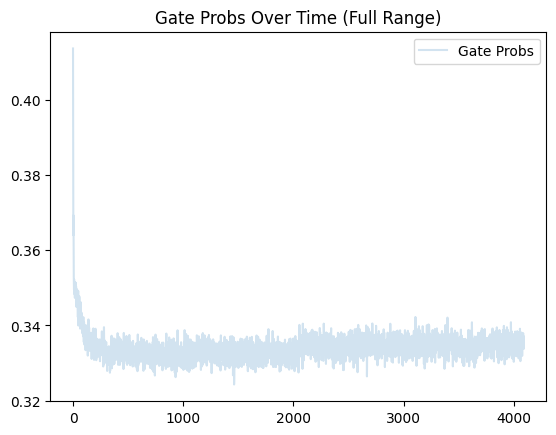

In [20]:
fig, ax1 = plt.subplots()
# Panel 1: Full limits
ax1.plot(mean_gate_probs, label='Gate Probs', alpha=0.2)
smoothed_gate_probs = smooth(mean_gate_probs)
# ax1.plot(range(len(mean_gate_probs) - len(smoothed_gate_probs), len(mean_gate_probs)), 
#             smoothed_gate_probs, label='Gate Probs (Smoothed)', alpha=1.0)
ax1.legend()
ax1.set_title('Gate Probs Over Time (Full Range)')

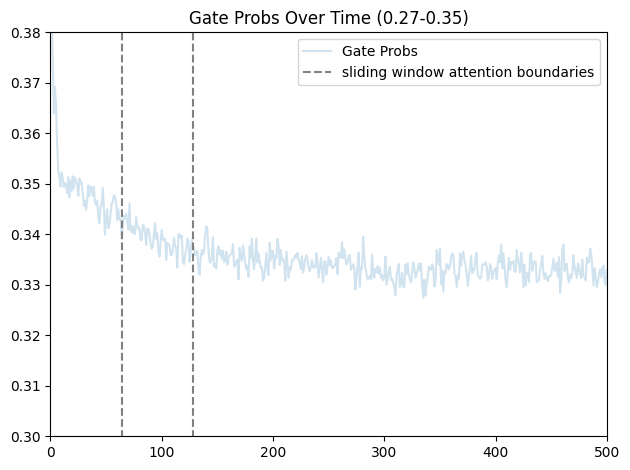

In [23]:
# Plot the gate probs over time.
fig, ax2 = plt.subplots()

# Panel 2: Limited y-axis between 0.23 and 0.35
ax2.plot(mean_gate_probs, label='Gate Probs', alpha=0.2)
# ax2.plot(range(len(mean_gate_probs) - len(smoothed_gate_probs), len(mean_gate_probs)), 
#             smoothed_gate_probs, label='Gate Probs (Smoothed)', alpha=1.0)
ax2.vlines(64, 0., 1., colors="gray", linestyles="dashed")
ax2.vlines(128, 0., 1., colors="gray", linestyles="dashed", label="sliding window attention boundaries")

ax2.set_ylim(0.3, 0.38)
ax2.set_xlim(0, 500)
ax2.legend()
ax2.set_title('Gate Probs Over Time (0.27-0.35)')
plt.tight_layout()
plt.savefig("plots/renders/gate_probs_over_time.png")
